DATA IMPORT AND PREPARATION

In [1]:
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm
import warnings
import numpy as np

df = pd.read_csv(
    '/content/drive/MyDrive/Doctorado/Artículo 2/datos_long_spss.csv',
    sep=';',
    decimal=',',
    encoding='utf-8'
)

# Convert categorical variables to category type for proper handling in mixed models
df["Half"] = df["Half"].astype("category")
df["HT_status"] = df["HT_status"].astype("category")
df["Ranking"] = df["Ranking"].astype("category")
df["TeamId"] = df["TeamId"].astype("category")
df["Match_ID"] = df["Match_ID"].astype("category")

# Create unique match-team identifier to account for non-independence of observations
df["MatchTeam"] = df["Match_ID"].astype(str) + "_" + df["TeamId"].astype(str)
df["MatchTeam"] = df["MatchTeam"].astype("category")

HIERARCHICAL MODEL FITTING WITH PROGRESSIVE COMPLEXITY  REDUCTION

In [2]:
# Dependent variables representing ball movement metrics
variables = ["Ownhalfperc", "Opphalfperc", "Velocity", "Distance", "Ground", "Aerial", "Time"]

# Store model results
results = {}

# Suppress warnings to avoid interrupting execution
warnings.filterwarnings("ignore")

for var in variables:
    print(f"\n### MODEL FOR {var} ###")

    # Define formulas in descending order of complexity
    formulas = [
        f"{var} ~ Half * HT_status * Ranking",            # Triple interaction
        f"{var} ~ Half * HT_status + Half * Ranking",    # Double interactions
        f"{var} ~ Half + HT_status + Ranking"            # Main effects only
    ]

    for formula in formulas:
        try:
            model = smf.mixedlm(
                formula,
                df,
                groups=df["MatchTeam"]
            )
            res = model.fit(method="lbfgs", maxiter=5000, reml=True)
            results[var] = res
            print(f"Model converged with formula: {formula}")
            break  # If convergence achieved, skip simpler specifications
        except (np.linalg.LinAlgError, ValueError) as e:
            print(f"Failed to converge with formula: {formula} → {e}")
            continue


### MODEL FOR Ownhalfperc ###
Model converged with formula: Ownhalfperc ~ Half * HT_status * Ranking

### MODEL FOR Opphalfperc ###
Failed to converge with formula: Opphalfperc ~ Half * HT_status * Ranking → Singular matrix
Failed to converge with formula: Opphalfperc ~ Half * HT_status + Half * Ranking → Singular matrix
Failed to converge with formula: Opphalfperc ~ Half + HT_status + Ranking → Singular matrix

### MODEL FOR Velocity ###
Failed to converge with formula: Velocity ~ Half * HT_status * Ranking → Singular matrix
Failed to converge with formula: Velocity ~ Half * HT_status + Half * Ranking → Singular matrix
Failed to converge with formula: Velocity ~ Half + HT_status + Ranking → Singular matrix

### MODEL FOR Distance ###
Model converged with formula: Distance ~ Half * HT_status * Ranking

### MODEL FOR Ground ###
Model converged with formula: Ground ~ Half * HT_status * Ranking

### MODEL FOR Aerial ###
Model converged with formula: Aerial ~ Half * HT_status * Ranking

#

FALLBACK MIXED-EFFECTS MODELING FOR PROBLEMATIC VARIABLES USING TEAM-LEVEL RANDOM EFFECTS



In [3]:
# Variables that failed to converge with MatchTeam random effect
problem_vars = ["Opphalfperc", "Velocity"]

# Store fallback model results
results_problem = {}

for var in problem_vars:
    print(f"\n### MODEL FOR {var} ###")

    # Use main effects only formula
    formula = f"{var} ~ Half + HT_status + Ranking"

    # Apply TeamId as random effect (simpler grouping structure that ensures convergence)
    model = smf.mixedlm(
        formula,
        df,
        groups=df["TeamId"]  # Only random effect structure that achieves convergence
    )

    # Fit model
    try:
        res = model.fit(method="lbfgs", maxiter=5000, reml=True)
        results_problem[var] = res
        print("Model converged ✅")
        print(res.summary())
    except Exception as e:
        results_problem[var] = None
        print(f"Failed to converge ❌: {e}")


### MODEL FOR Opphalfperc ###
Model converged ✅
                 Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      Opphalfperc
No. Observations:      1516         Method:                  REML       
No. Groups:            20           Scale:                   69.2310    
Min. group size:       74           Log-Likelihood:          inf        
Max. group size:       76           Converged:               Yes        
Mean group size:       75.8                                             
------------------------------------------------------------------------
               Coef.   Std.Err.     z   P>|z|     [0.025       0.975]   
------------------------------------------------------------------------
Intercept      2.044 22645320.217 0.000 1.000 -44384010.001 44384014.089
Half[T.2]      3.225        0.427 7.545 0.000         2.387        4.062
HT_status[T.1] 1.651        0.565 2.922 0.003         0.544        2.759
HT_status[T.2] 0.689

MODEL SUMMARY OUTPUT FOR CONVERGED MIXED-EFFECTS MODELS

In [4]:
for var, res in results.items():
    print(f"\n=== RESULTS FOR {var} ===\n")
    print(res.summary())


=== RESULTS FOR Ownhalfperc ===

                      Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         Ownhalfperc
No. Observations:         1516            Method:                     REML       
No. Groups:               758             Scale:                      38.3380    
Min. group size:          2               Log-Likelihood:             -5283.2635 
Max. group size:          2               Converged:                  Yes        
Mean group size:          2.0                                                    
---------------------------------------------------------------------------------
                                      Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------------------------------
Intercept                             54.242    1.599 33.931 0.000  51.109 57.375
Half[T.2]                             -9.311    1.599 -5.824 0.000 -12.445 -6.178
HT_s

SYSTEMATIC ESTIMATION OF HALF-TO-HALF CHANGES ACROSS ALL CONVERGED BALL MOVEMENT METRICS

In [5]:
def extract_half_changes(res, variable_name):
    """Extract estimated second-half changes (P2 – P1) across Ranking × HT_status combinations"""
    params = res.params

    def get_effect(name):
        return params.get(name, 0.0)

    rows = []
    rankings = [1, 2, 3, 4, 5]
    statuses = [0, 1, 2]  # 0=losing (reference), 1=drawing, 2=winning

    for r in rankings:
        for s in statuses:
            # Base half effect
            change = get_effect("Half[T.2]")

            # Half × HT_status interaction
            if s == 1:
                change += get_effect("Half[T.2]:HT_status[T.1]")
            elif s == 2:
                change += get_effect("Half[T.2]:HT_status[T.2]")

            # Half × Ranking interaction
            if r != 1:
                change += get_effect(f"Half[T.2]:Ranking[T.{r}]")

            # Triple interaction (when applicable)
            if s != 0 and r != 1:
                ht_suffix = "T.1" if s == 1 else "T.2"
                change += get_effect(f"Half[T.2]:HT_status[{ht_suffix}]:Ranking[T.{r}]")

            rows.append({
                "Variable": variable_name,
                "Ranking": r,
                "HT_status": s,
                "Estimated_Change_P2_minus_P1": change
            })

    return pd.DataFrame(rows)

# Apply to the five variables that converged with MatchTeam random effect
converged_vars = ["Ownhalfperc", "Distance", "Ground", "Aerial", "Time"]
all_changes = []

for var in converged_vars:
    df_var = extract_half_changes(results[var], var)
    all_changes.append(df_var)

# Combine into single dataframe for export and inspection
df_all_changes = pd.concat(all_changes, ignore_index=True)
df_all_changes.to_csv("estimated_half_changes_converged_variables.csv", index=False)
df_all_changes

,Variable,Ranking,HT_status,Estimated_Change_P2_minus_P1
0,Ownhalfperc,1,0,-9.311255
1,Ownhalfperc,1,1,-3.084162
2,Ownhalfperc,1,2,2.489451
3,Ownhalfperc,2,0,-7.214591
4,Ownhalfperc,2,1,-3.365633
...,...,...,...,...
70,Time,4,1,23.002353
71,Time,4,2,-29.548679
72,Time,5,0,53.396000
73,Time,5,1,36.049655


OMNIBUS F-TESTS FOR HIERARCHICAL INTERACTION EFFECTS ON THE BALL-MOVEMENT VARIABLES

In [6]:
# Variables that converged with MatchTeam random effect structure
converged_vars = ["Ownhalfperc", "Distance", "Ground", "Aerial", "Time"]

for var in converged_vars:
    print(f"\n{'='*70}")
    print(f"OMNIBUS F-TESTS FOR: {var.upper()}")
    print(f"{'='*70}\n")

    res = results[var]

    # --- Test 1: Half × HT_status interaction ---
    try:
        f_test1 = res.f_test("Half[T.2]:HT_status[T.1] = Half[T.2]:HT_status[T.2] = 0")
        print("▶ Half × HT_status interaction:")
        print(f"  F({f_test1.df_num:.0f}, {f_test1.df_denom:.0f}) = {f_test1.fvalue:.3f}, p = {f_test1.pvalue:.4f}")
    except Exception as e:
        print(f"▶ Half × HT_status interaction: NOT TESTED ({str(e).split(':')[0]})")

    # --- Test 2: Half × Ranking interaction ---
    try:
        constraints_ranking = " = ".join([
            f"Half[T.2]:Ranking[T.{r}]" for r in range(2, 6)
        ]) + " = 0"
        f_test2 = res.f_test(constraints_ranking)
        print("\n▶ Half × Ranking interaction:")
        print(f"  F({f_test2.df_num:.0f}, {f_test2.df_denom:.0f}) = {f_test2.fvalue:.3f}, p = {f_test2.pvalue:.4f}")
    except Exception as e:
        print(f"\n▶ Half × Ranking interaction: NOT TESTED ({str(e).split(':')[0]})")

    # --- Test 3: Triple interaction (Half × HT_status × Ranking) ---
    try:
        triple_terms = []
        for r in range(2, 6):
            for s in [1, 2]:
                triple_terms.append(f"Half[T.2]:HT_status[T.{s}]:Ranking[T.{r}]")
        constraints_triple = " = ".join(triple_terms) + " = 0"
        f_test3 = res.f_test(constraints_triple)
        print("\n▶ Triple interaction (Half × HT_status × Ranking):")
        print(f"  F({f_test3.df_num:.0f}, {f_test3.df_denom:.0f}) = {f_test3.fvalue:.3f}, p = {f_test3.pvalue:.4f}")
    except Exception as e:
        print(f"\n▶ Triple interaction: NOT TESTED ({str(e).split(':')[0]})")

    print()


OMNIBUS F-TESTS FOR: OWNHALFPERC

▶ Half × HT_status interaction:
  F(2, 1486) = 21.830, p = 0.0000

▶ Half × Ranking interaction:
  F(4, 1486) = 1.528, p = 0.1915

▶ Triple interaction (Half × HT_status × Ranking):
  F(8, 1486) = 1.880, p = 0.0593


OMNIBUS F-TESTS FOR: DISTANCE

▶ Half × HT_status interaction:
  F(2, 1486) = 5.315, p = 0.0050

▶ Half × Ranking interaction:
  F(4, 1486) = 2.341, p = 0.0531

▶ Triple interaction (Half × HT_status × Ranking):
  F(8, 1486) = 0.862, p = 0.5478


OMNIBUS F-TESTS FOR: GROUND

▶ Half × HT_status interaction:
  F(2, 1486) = 5.018, p = 0.0067

▶ Half × Ranking interaction:
  F(4, 1486) = 2.305, p = 0.0564

▶ Triple interaction (Half × HT_status × Ranking):
  F(8, 1486) = 0.697, p = 0.6948


OMNIBUS F-TESTS FOR: AERIAL

▶ Half × HT_status interaction:
  F(2, 1486) = 0.104, p = 0.9010

▶ Half × Ranking interaction:
  F(4, 1486) = 0.991, p = 0.4111

▶ Triple interaction (Half × HT_status × Ranking):
  F(8, 1486) = 1.659, p = 0.1039


OMNIBUS F-T

HEATMAP FOR ESTIMATED CHANGES

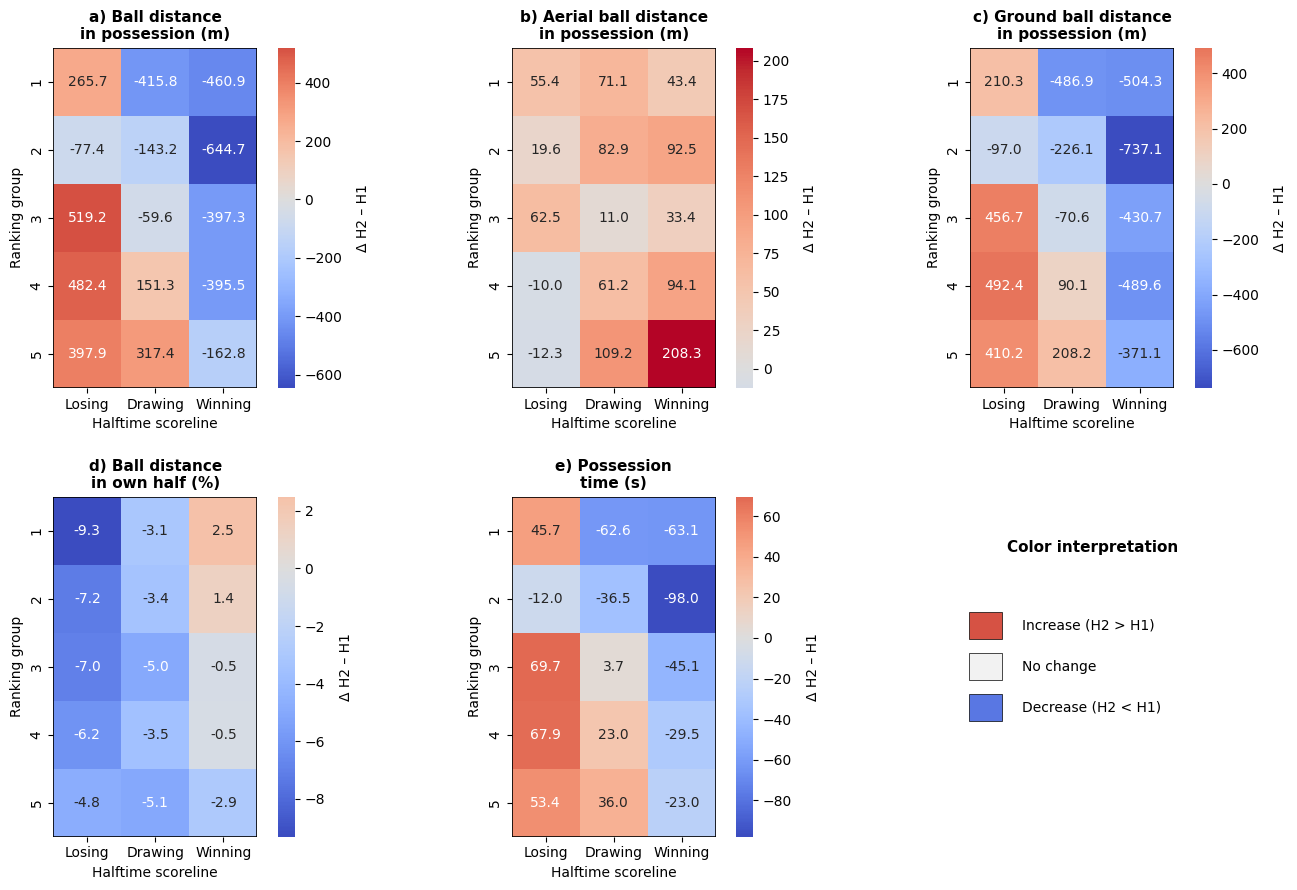

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---------- Function to create the heatmap DataFrame ----------
def create_heatmap_df(df_all_changes, variable):
    df_var = df_all_changes[df_all_changes["Variable"] == variable].copy()
    df_var["HT_status_label"] = df_var["HT_status"].map({
        0: "Losing",
        1: "Drawing",
        2: "Winning"
    })

    hm = df_var.pivot(
        index="Ranking",
        columns="HT_status_label",
        values="Estimated_Change_P2_minus_P1"
    )

    return hm.reindex(columns=["Losing", "Drawing", "Winning"])


# ---------- Variable order ----------
ordered_vars = ["Distance", "Aerial", "Ground", "Ownhalfperc", "Time"]

# ---------- Titles in two lines (journal style) ----------
var_labels = {
    "Distance": "a) Ball distance\nin possession (m)",
    "Aerial": "b) Aerial ball distance\nin possession (m)",
    "Ground": "c) Ground ball distance\nin possession (m)",
    "Ownhalfperc": "d) Ball distance\nin own half (%)",
    "Time": "e) Possession\ntime (s)"
}


# ---------- Figure ----------
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()


# ---------- Heatmaps ----------
for i, var in enumerate(ordered_vars):
    hm_df = create_heatmap_df(df_all_changes, var)

    ax = axes[i]

    # Draw a black rectangle behind the heatmap for the border
    ax.add_patch(
        Rectangle(
            (0, 0),
            width=hm_df.shape[1],
            height=hm_df.shape[0],
            fill=False,
            edgecolor="black",
            linewidth=1.2,
            transform=ax.transData,
            zorder=1000
        )
    )

    sns.heatmap(
        hm_df,
        annot=True,
        fmt=".1f",
        cmap="coolwarm",
        center=0,
        square=True,
        cbar=True,
        cbar_kws={"label": "Δ H2 – H1"},  # only the label text here
        ax=ax
    )

    # Access the colorbar and adjust label padding
    cbar = ax.collections[0].colorbar
    cbar.set_label("Δ H2 – H1", labelpad=10)

    ax.set_title(
        var_labels[var],
        fontweight="bold",
        fontsize=11
    )

    ax.set_xlabel("Halftime scoreline")
    ax.set_ylabel("Ranking group")


# ---------- Sixth panel: iconographic color legend ----------
ax_leg = axes[5]
ax_leg.axis("off")

legend_x = 0.60

ax_leg.text(
    legend_x, 0.85,
    "Color interpretation",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold"
)

legend_items = [
    ("Increase (H2 > H1)", plt.cm.coolwarm(0.9)),
    ("No change", "#f2f2f2"),
    ("Decrease (H2 < H1)", plt.cm.coolwarm(0.1))
]

y_positions = [0.62, 0.5, 0.38]

for (label, color), y in zip(legend_items, y_positions):
    ax_leg.add_patch(
        Rectangle(
            (legend_x - 0.30, y - 0.04),
            0.08,
            0.08,
            facecolor=color,
            edgecolor="black",
            linewidth=0.5
        )
    )
    ax_leg.text(
        legend_x - 0.17, y,
        label,
        ha="left",
        va="center",
        fontsize=10
    )


# ---------- Final adjustments ----------
plt.tight_layout(w_pad=1.0, h_pad=2.0)
plt.show()


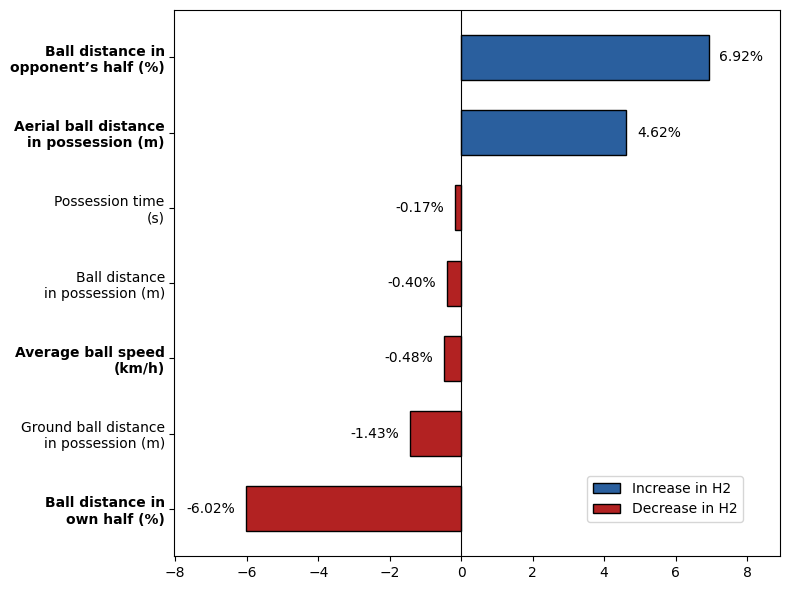

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# ---------- Data ----------
data = {
    "Variable": [
        "Distance",
        "Aerial",
        "Ground",
        "Ownhalfperc",
        "Opphalfperc",
        "Time",
        "Velocity"
    ],
    "Label": [
        "Ball distance\nin possession (m)",
        "Aerial ball distance\nin possession (m)",
        "Ground ball distance\nin possession (m)",
        "Ball distance in\nown half (%)",
        "Ball distance in\nopponent’s half (%)",
        "Possession time\n(s)",
        "Average ball speed\n(km/h)"
    ],
    "H1": [6270.12, 1064.66, 5205.46, 53.47, 46.53, 838.25, 27.12],
    "H2": [6245.18, 1113.90, 5131.28, 50.25, 49.75, 836.85, 26.99],
    "p": [0.548, 0.001, 0.081, 0.001, 0.001, 0.818, 0.023]
}

df = pd.DataFrame(data)

# ---------- Calculate relative change in percentage ----------
df["RelChange"] = ((df["H2"] - df["H1"]) / df["H1"]) * 100

# ---------- Sort from most positive to most negative ----------
df = df.sort_values("RelChange", ascending=False).reset_index(drop=True)

# ---------- Reverse order ----------
df = df.iloc[::-1].reset_index(drop=True)

# ---------- Colors (intermediate shades) ----------
colors = ["#2a5f9e" if x >= 0 else "#b22222" for x in df["RelChange"]]

# ---------- Create figure ----------
fig, ax = plt.subplots(figsize=(8,6))
bars = ax.barh(range(len(df)), df["RelChange"], color=colors, edgecolor="black", height=0.6)

# ---------- Set variable names and bold if significant ----------
yticks = []
for i, row in df.iterrows():
    fontweight = "bold" if row["p"] < 0.05 else "normal"
    yticks.append((i, row["Label"], fontweight))

ax.set_yticks([y[0] for y in yticks])
ax.set_yticklabels([y[1] for y in yticks])

# Apply fontweight individually
for i, tick_label in enumerate(ax.get_yticklabels()):
    tick_label.set_fontweight(yticks[i][2])

# ---------- Adjust x-axis limits ----------
buffer = 2
x_min = df["RelChange"].min() - buffer
x_max = df["RelChange"].max() + buffer
ax.set_xlim(x_min, x_max)

# ---------- Annotate percentage outside bars ----------
for i, bar in enumerate(bars):
    width = bar.get_width()
    label_text = f"{width:.2f}%"
    xpos = width + 0.3 if width >= 0 else width - 0.3
    ha = "left" if width >= 0 else "right"

    ax.text(
        xpos,
        bar.get_y() + bar.get_height()/2,
        label_text,
        ha=ha,
        va="center",
        color="black"
    )

# ---------- Legend ----------
legend_elements = [
    Patch(facecolor="#2a5f9e", edgecolor="black", label="Increase in H2"),
    Patch(facecolor="#b22222", edgecolor="black", label="Decrease in H2")
]
ax.legend(
    handles=legend_elements,
    loc="lower right",
    bbox_to_anchor=(0.95, 0.05),
    frameon=True,
    fontsize=10
)


# ---------- Final adjustments ----------
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()
